# 📊 Matplotlib — Manual completo de gráficos para análisis de datos

**Para:** Borja
**Módulo:** 4 — Visualización

> 📌 Reutilizamos exactamente las variables que ya preparaste
> (`datos_1d`, `x`, `y`, `valores`, `categorias`, `fechas`,
> `valores_tiempo`, `df`), dándoles ahora un contexto de negocio para que
> cada gráfico tenga sentido real, no solo números sueltos.

**Índice de lo que vas a dominar:**

1. La anatomía de un gráfico: `Figure` y `Axes`.
2. Gráfico de líneas — evolución en el tiempo.
3. Diagrama de dispersión — relación entre dos variables.
4. Gráfico de barras — comparar categorías.
5. Histograma — distribución de un conjunto de datos.
6. Gráfico de tarta — proporciones de un total.
7. Boxplot — distribución y outliers de varias variables a la vez.
8. Subplots — varios gráficos en una sola figura.
9. Personalización: colores, leyendas, anotaciones, estilos.
10. Guardar gráficos a fichero.
11. Un "dashboard" final que junta varios gráficos, nivel profesional.


## 1. La anatomía de un gráfico: `Figure` y `Axes`

**Qué es:** Matplotlib organiza cualquier gráfico en dos piezas: la
`Figure` (el lienzo completo, puede contener varios gráficos) y el `Axes`
(cada gráfico individual dentro de ese lienzo, con sus propios ejes X e Y).

### 🎈 Analogía sencilla

Una `Figure` es como una **hoja de papel** en blanco. Un `Axes` es **un
dibujo concreto** dentro de esa hoja — en una hoja puedes tener un solo
dibujo, o puedes dividirla en una cuadrícula y poner varios dibujos
distintos, uno en cada hueco.

### 📊 Representación visual

```
┌─────────────── Figure (la hoja completa) ───────────────┐
│                                                           │
│   ┌─────────────── Axes (un gráfico) ─────────────────┐  │
│   │                                                     │  │
│   │     ╱╲      título, ejes X/Y, leyenda, etc.         │  │
│   │    ╱  ╲                                             │  │
│   │   ╱    ╲___                                         │  │
│   └─────────────────────────────────────────────────────┘  │
│                                                           │
└───────────────────────────────────────────────────────────┘
```

### 🐍 Las dos formas de trabajar con Matplotlib

Vas a ver ambos estilos en código real, así que conviene reconocerlos:

- **Estilo `pyplot` (rápido, implícito):** `plt.plot(...)`, `plt.title(...)`.
  Es como un mando a distancia que siempre apunta "al gráfico activo en este
  momento" — cómodo para un único gráfico rápido.
- **Estilo orientado a objetos (explícito, recomendado):**
  `fig, ax = plt.subplots()`, y luego `ax.plot(...)`, `ax.set_title(...)`.
  Aquí tienes una referencia directa al `Axes` concreto sobre el que
  trabajas — imprescindible en cuanto tengas más de un gráfico en la misma
  figura.

Usaremos sobre todo el estilo orientado a objetos, porque escala mejor y es
el que verás en código profesional.

### 🐍 Código Python: nuestro primer `Axes`


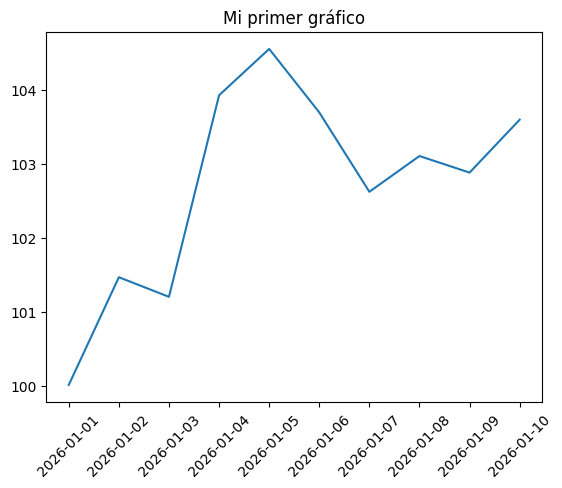

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Las mismas variables que ya preparaste, ahora con contexto de negocio:
datos_1d = np.random.randn(100) * 5 + 20       # tiempos de respuesta de una web (segundos)
x = np.random.rand(50) * 1000                  # inversión en marketing (€)
y = x * 0.8 + np.random.rand(50) * 200          # ventas generadas (€)
valores = [35, 25, 40]                          # cuota de mercado por región
categorias = ["Norte", "Centro", "Sur"]
fechas = pd.date_range(start="2026-01-01", periods=10)
valores_tiempo = np.cumsum(np.random.randn(10)) + 100   # ventas acumuladas
df = pd.DataFrame(
    np.random.rand(10, 4) * 100,
    columns=["Ventas", "Costes", "Beneficio", "Clientes"],
)

fig, ax = plt.subplots()
ax.plot(fechas, valores_tiempo)
ax.set_title("Mi primer gráfico")
ax.tick_params(axis="x", rotation=45)
plt.show()


### 🔍 Explicación línea a línea

- `fig, ax = plt.subplots()` → crea una `Figure` y, dentro, un único
  `Axes`, y te devuelve **ambos** por separado para que puedas controlarlos.
- `ax.plot(...)` → dibuja sobre ese `Axes` concreto.
- `plt.show()` → renderiza y muestra el gráfico. En un notebook, sin
  `plt.show()` a veces el gráfico se muestra igual al final de la celda,
  pero es buena práctica incluirlo siempre — sobre todo si vas a dibujar
  varios gráficos en celdas distintas.

### 💼 Aplicación profesional

El estilo orientado a objetos (`fig, ax`) es el que necesitarás en cuanto
quieras montar un dashboard con varios gráficos a la vez — lo verás en la
sección de `subplots` más adelante.

---

### 📝 Ejercicio 1 (básico) — Tu primer `Axes`

Crea una `fig, ax` y dibuja `datos_1d` con `ax.plot()`. Ponle un título con
`ax.set_title("Tiempos de respuesta")`.


In [2]:
# Ejercicio 1 — Tu código aquí


#### 💡 Solución — Ejercicio 1


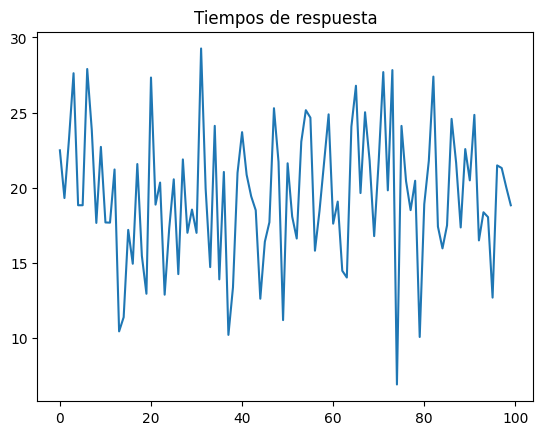

In [3]:
fig, ax = plt.subplots()
ax.plot(datos_1d)
ax.set_title("Tiempos de respuesta")
plt.show()


## 2. Gráfico de líneas — evolución en el tiempo

**Qué es:** conecta puntos consecutivos con una línea. Es el gráfico por
defecto para mostrar cómo cambia algo a lo largo del tiempo.

**Cuándo se usa:** ventas mes a mes, evolución de un KPI, cualquier serie
ordenada por fecha.

### 🐍 Código Python


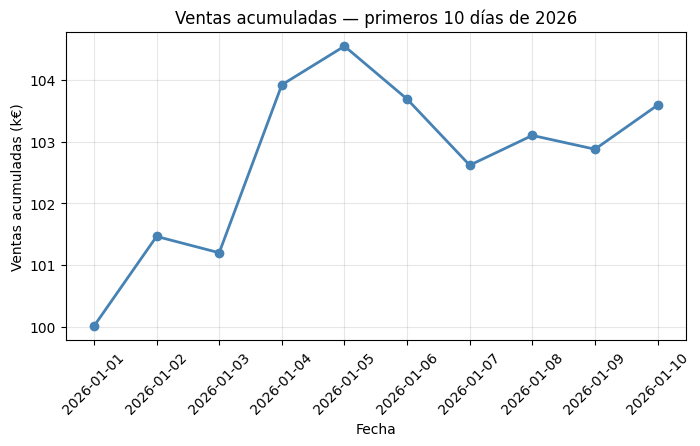

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fechas, valores_tiempo, color="steelblue", marker="o", linewidth=2)

ax.set_title("Ventas acumuladas — primeros 10 días de 2026")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas acumuladas (k€)")
ax.grid(True, alpha=0.3)
ax.tick_params(axis="x", rotation=45)

plt.show()


### 🔍 Explicación línea a línea

- `figsize=(8, 4)` → tamaño del lienzo en pulgadas (ancho, alto). Controla
  el tamaño final de la imagen.
- `color=`, `marker=`, `linewidth=` → estética de la línea: color, forma de
  los puntos en cada dato (`"o"` = círculo), y grosor de la línea.
- `ax.set_xlabel()` / `ax.set_ylabel()` → etiquetas de los ejes — un
  gráfico sin etiquetas en los ejes no es un gráfico profesional, por bonito
  que sea.
- `ax.grid(True, alpha=0.3)` → una rejilla de fondo suave (`alpha` controla
  la transparencia, de `0` invisible a `1` totalmente opaco), que ayuda a
  leer valores aproximados sin que distraiga del dato principal.

### ⚠️ Error común

Olvidar `ax.set_xlabel()`/`ax.set_ylabel()`/`ax.set_title()` — un gráfico
sin contexto obliga a quien lo lea a adivinar qué está viendo. Siempre que
entregues un gráfico (a un jefe, a un cliente, en un informe), estas 3
etiquetas son obligatorias, no opcionales.

### 💼 Aplicación profesional

El gráfico de líneas es, con diferencia, el más usado en informes de
negocio para mostrar tendencias — el equivalente del gráfico de líneas que
ya conoces de Power BI.

---

### 📝 Ejercicio 2 (básico) — Dos líneas en el mismo gráfico

Crea dos series nuevas: `ventas_plan = valores_tiempo * 1.1` (el objetivo) y
dibuja, en el mismo `Axes`, tanto `valores_tiempo` como `ventas_plan`, cada
una con un color distinto, y añade una leyenda con `ax.legend()`.


In [5]:
# Ejercicio 2 — Tu código aquí


#### 💡 Solución — Ejercicio 2


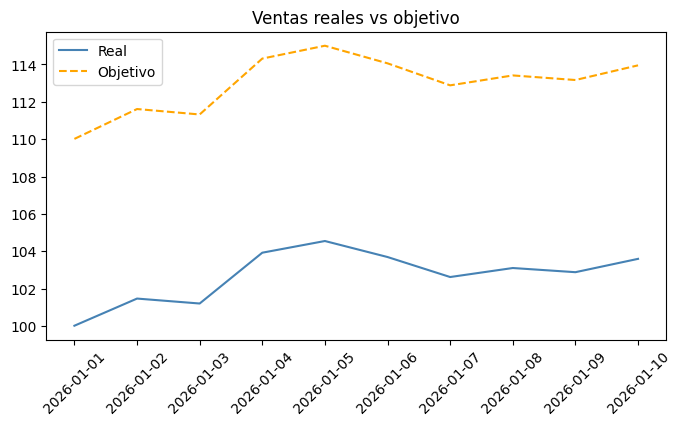

In [6]:
ventas_plan = valores_tiempo * 1.1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fechas, valores_tiempo, label="Real", color="steelblue")
ax.plot(fechas, ventas_plan, label="Objetivo", color="orange", linestyle="--")

ax.set_title("Ventas reales vs objetivo")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.show()


> 💡 `label="..."` en cada `.plot()` es lo que hace que `ax.legend()` sepa
> qué texto poner junto a cada línea. Sin `label`, `legend()` no tendría
> nada que mostrar.


## 3. Diagrama de dispersión (`scatter`) — relación entre dos variables

**Qué es:** un punto por cada par de valores `(x, y)`, sin conectarlos con
líneas. Sirve para ver si dos variables están relacionadas entre sí.

**Cuándo se usa:** ¿más inversión en marketing genera más ventas? ¿la edad
del cliente influye en el importe de compra?

### 🐍 Código Python


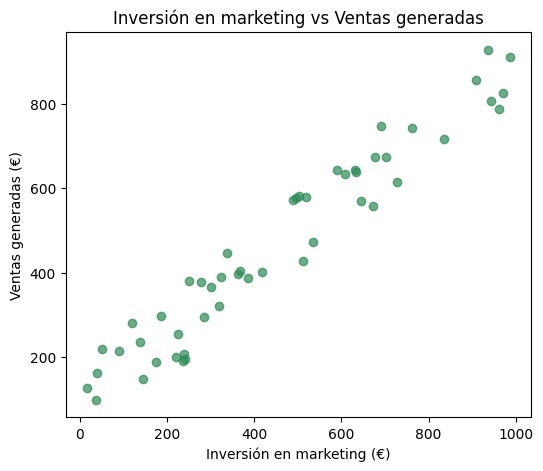

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y, color="seagreen", alpha=0.7)

ax.set_title("Inversión en marketing vs Ventas generadas")
ax.set_xlabel("Inversión en marketing (€)")
ax.set_ylabel("Ventas generadas (€)")

plt.show()


### 🐍 Código Python: añadiendo una tercera dimensión con color y tamaño


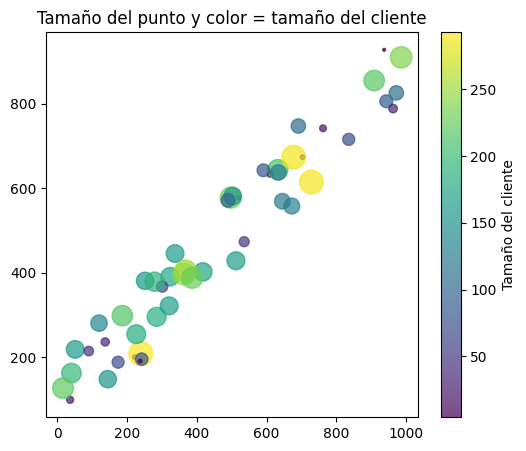

In [8]:
tamano_cliente = np.random.rand(50) * 300

fig, ax = plt.subplots(figsize=(6, 5))
dispersión = ax.scatter(x, y, c=tamano_cliente, s=tamano_cliente, cmap="viridis", alpha=0.7)

ax.set_title("Tamaño del punto y color = tamaño del cliente")
fig.colorbar(dispersión, label="Tamaño del cliente")

plt.show()


### 🔍 Explicación línea a línea

- `ax.scatter(x, y, color=..., alpha=...)` → un punto por cada par
  `(x[i], y[i])`. `alpha` ayuda cuando hay puntos solapados (más
  transparente = puedes distinguir zonas con más densidad de puntos).
- `c=tamano_cliente` → en vez de un color fijo, cada punto se colorea según
  el valor de una **tercera variable** — el color se convierte en una
  dimensión más de información.
- `s=tamano_cliente` → el **tamaño** de cada punto también puede variar
  según otra variable (puede ser la misma que el color, o una distinta).
- `cmap="viridis"` → la paleta de colores que se usa para traducir números
  a colores (*colormap*). Hay muchas (`"plasma"`, `"coolwarm"`,
  `"Blues"`...).
- `fig.colorbar(dispersión, ...)` → añade la leyenda de color al lado del
  gráfico, para que se pueda leer qué significa cada tono.

### 💼 Aplicación profesional

Un scatter con color y tamaño es una forma muy potente de mostrar **3 o 4
variables a la vez** en un solo gráfico 2D — algo que en una tabla pivote
normal no se puede hacer de un vistazo.

---

### 📝 Ejercicio 3 (intermedio) — Dispersión con línea de tendencia

Sobre `x` e `y`, dibuja el scatter, y superpón una línea de tendencia usando
`np.polyfit(x, y, 1)` para calcular la pendiente y el punto de corte, y
`ax.plot()` para dibujar esa línea recta encima.


In [9]:
# Ejercicio 3 — Tu código aquí


#### 💡 Solución — Ejercicio 3


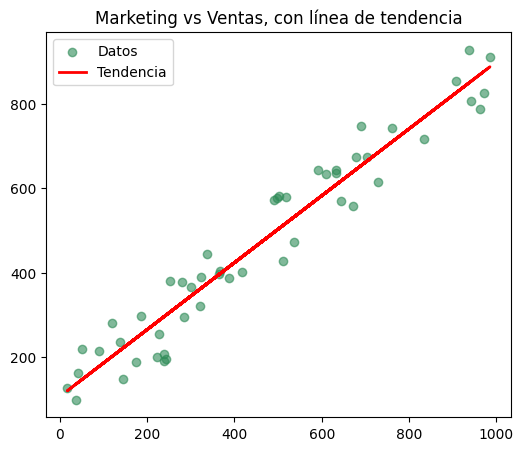

In [10]:
pendiente, corte = np.polyfit(x, y, 1)
linea_tendencia = pendiente * x + corte

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y, color="seagreen", alpha=0.6, label="Datos")
ax.plot(x, linea_tendencia, color="red", linewidth=2, label="Tendencia")

ax.set_title("Marketing vs Ventas, con línea de tendencia")
ax.legend()
plt.show()


> 💡 `np.polyfit(x, y, 1)` ajusta una recta (`grado=1`) a la nube de puntos,
> devolviendo la pendiente y el punto de corte con el eje Y — la misma idea
> que una línea de tendencia que añadirías a un gráfico de Excel/Power BI.


## 4. Gráfico de barras — comparar categorías

**Qué es:** una barra por categoría, cuya altura (o longitud, si es
horizontal) representa un valor.

**Cuándo se usa:** comparar ventas por región, por producto, por
vendedor — cualquier comparación entre grupos discretos.

### 🐍 Código Python


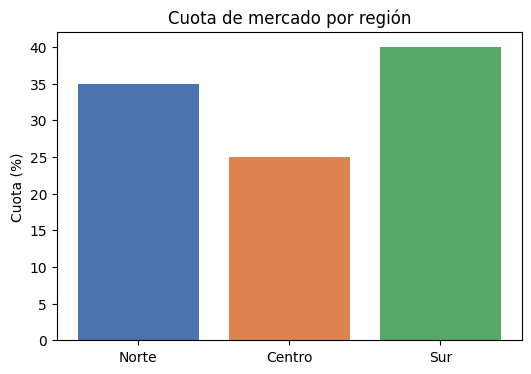

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(categorias, valores, color=["#4C72B0", "#DD8452", "#55A868"])

ax.set_title("Cuota de mercado por región")
ax.set_ylabel("Cuota (%)")

plt.show()


### 🐍 Código Python: barras horizontales (`barh`)


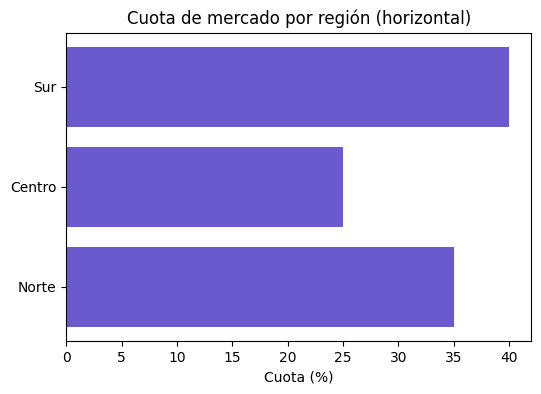

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(categorias, valores, color="slateblue")

ax.set_title("Cuota de mercado por región (horizontal)")
ax.set_xlabel("Cuota (%)")

plt.show()


### 🔍 Explicación línea a línea

- `ax.bar(categorias, valores, color=[...])` → una lista de colores, uno
  por barra, en el mismo orden que las categorías.
- `ax.barh(...)` → exactamente lo mismo, pero en horizontal — muy útil
  cuando los nombres de las categorías son largos y no caben bien debajo de
  barras verticales.

### ⚠️ Error común

Pasar una lista de colores con **menos** elementos que categorías —
Matplotlib reciclará los colores desde el principio, lo que puede confundir
si no te das cuenta.

### 💼 Aplicación profesional

Ordenar las barras de mayor a menor (en vez de dejarlas en el orden
"natural" de los datos) suele hacer el gráfico mucho más legible — es una
decisión de diseño, no una obligación de Matplotlib.

---

### 📝 Ejercicio 4 (intermedio) — Barras ordenadas de mayor a menor

Usando `categorias` y `valores`, ordénalos de mayor a menor valor antes de
dibujar el gráfico de barras (pista: puedes usar `np.argsort` sobre
`valores`, igual que hiciste en el notebook de NumPy).


In [13]:
# Ejercicio 4 — Tu código aquí


#### 💡 Solución — Ejercicio 4


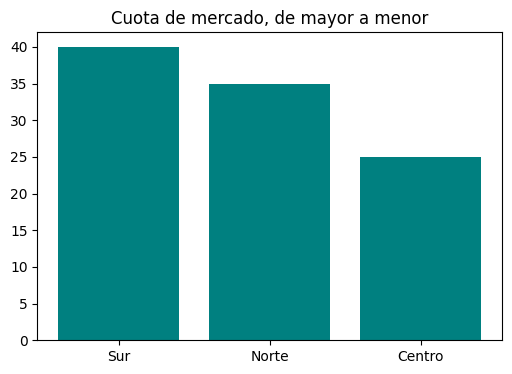

In [14]:
orden = np.argsort(valores)[::-1]   # argsort ordena de menor a mayor; [::-1] invierte para mayor a menor
categorias_ordenadas = np.array(categorias)[orden]
valores_ordenados = np.array(valores)[orden]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(categorias_ordenadas, valores_ordenados, color="teal")
ax.set_title("Cuota de mercado, de mayor a menor")
plt.show()


## 5. Histograma — distribución de un conjunto de datos

**Qué es:** agrupa los valores numéricos en "cajones" (*bins*) de rangos
iguales, y dibuja una barra con cuántos valores caen en cada cajón.

**Cuándo se usa:** ¿cómo se distribuyen los tiempos de respuesta de la
web? ¿la mayoría de clientes gastan poco, o hay mucha variedad?

### 🐍 Código Python


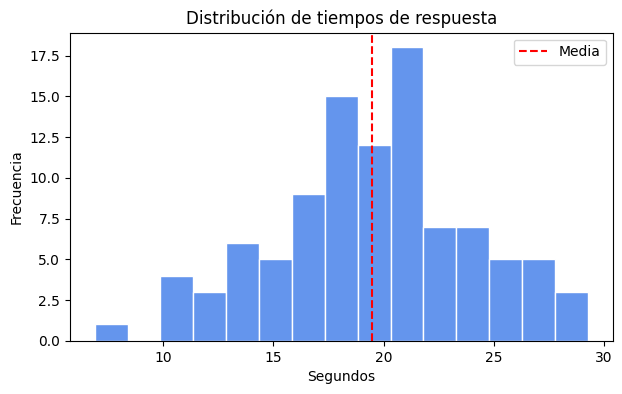

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(datos_1d, bins=15, color="cornflowerblue", edgecolor="white")

ax.set_title("Distribución de tiempos de respuesta")
ax.set_xlabel("Segundos")
ax.set_ylabel("Frecuencia")
ax.axvline(datos_1d.mean(), color="red", linestyle="--", label="Media")
ax.legend()

plt.show()


### 🔍 Explicación línea a línea

- `bins=15` → en cuántos cajones se reparten los datos. Pocos `bins`
  simplifican demasiado la forma; demasiados hacen que parezca ruido — hay
  que probar un par de valores para encontrar el que mejor cuenta la
  historia.
- `edgecolor="white"` → un borde entre barras adyacentes, para que se
  distingan visualmente unas de otras.
- `ax.axvline(valor, ...)` → dibuja una línea **vertical** en una posición
  concreta del eje X — perfecto para marcar la media, una meta, o un
  límite, encima del histograma.

### ⚠️ Error común

No probar distintos valores de `bins`. El mismo dataset puede "parecer"
tener una distribución completamente distinta según cuántos cajones uses —
siempre vale la pena probar 2 o 3 valores antes de quedarte con uno.

### 💼 Aplicación profesional

El histograma es tu primera herramienta para entender la "forma" de una
variable numérica antes de cualquier análisis más avanzado — ¿está
centrada, sesgada, tiene dos picos (bimodal)? Esa forma condiciona qué
estadísticas tienen sentido usar después.

---

### 📝 Ejercicio 5 (intermedio) — Comparar 2 histogramas de bins distintos

Dibuja `datos_1d` dos veces, en el mismo `Axes`, con `bins=5` y `bins=40`
respectivamente, usando `alpha` para que se vean ambos superpuestos, y una
leyenda que diga qué `bins` tiene cada uno.


In [16]:
# Ejercicio 5 — Tu código aquí


#### 💡 Solución — Ejercicio 5


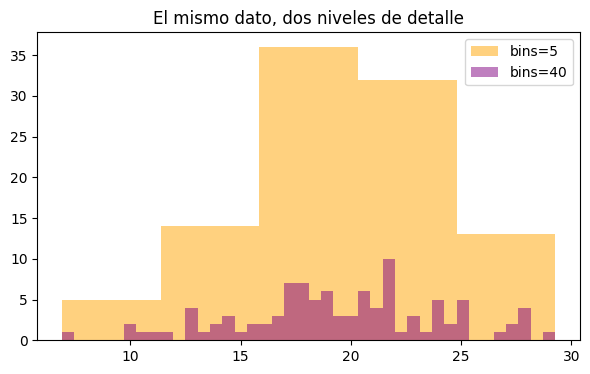

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(datos_1d, bins=5, alpha=0.5, label="bins=5", color="orange")
ax.hist(datos_1d, bins=40, alpha=0.5, label="bins=40", color="purple")

ax.set_title("El mismo dato, dos niveles de detalle")
ax.legend()
plt.show()


## 6. Gráfico de tarta (`pie`) — proporciones de un total

**Qué es:** divide un círculo en porciones proporcionales a cada valor,
respecto al total.

**Cuándo se usa:** cuota de mercado, reparto de presupuesto por categoría —
**solo** cuando de verdad importa "qué porcentaje del total" representa
cada parte, y hay pocas categorías (más de 5-6 porciones se vuelven
ilegibles).

### 🐍 Código Python


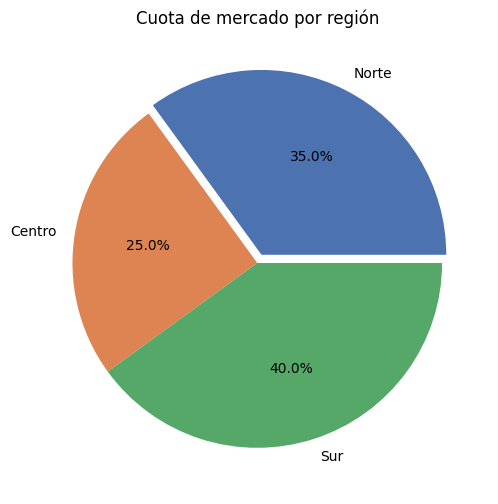

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    valores,
    labels=categorias,
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452", "#55A868"],
    explode=[0.05, 0, 0],
)
ax.set_title("Cuota de mercado por región")

plt.show()


### 🔍 Explicación línea a línea

- `autopct="%1.1f%%"` → muestra el porcentaje de cada porción, con 1
  decimal (la sintaxis viene del formateo de texto clásico de Python, no de
  f-strings — `%%` representa un símbolo `%` literal).
- `explode=[0.05, 0, 0]` → "separa" ligeramente la primera porción del
  resto del círculo, para destacarla — un valor por categoría, en el mismo
  orden.

### ⚠️ Error común — y una opinión profesional importante

Los gráficos de tarta tienen mala fama entre analistas de datos
experimentados: el ojo humano compara **ángulos** peor de lo que compara
**longitudes de barra**. Con más de 4-5 categorías, o cuando los valores son
parecidos entre sí, un gráfico de barras casi siempre comunica mejor la
misma información. Úsalo con moderación, y solo cuando "parte de un total"
sea literalmente el mensaje que quieres transmitir.

### 💼 Aplicación profesional

Si dudas entre tarta y barras para el mismo dato, en un entorno
profesional la opción por defecto debería ser barras — la tarta es la
excepción, no la norma.

---

### 📝 Ejercicio 6 (intermedio) — Tarta con 5 categorías

Crea un nuevo conjunto de 5 categorías y 5 valores que tú inventes, y dibuja
un gráfico de tarta. Después, dibuja el **mismo** dato como gráfico de
barras. Compara a ojo cuál de los dos te permite ordenar mentalmente las
categorías de mayor a menor más rápido.


In [19]:
# Ejercicio 6 — Tu código aquí


#### 💡 Solución — Ejercicio 6


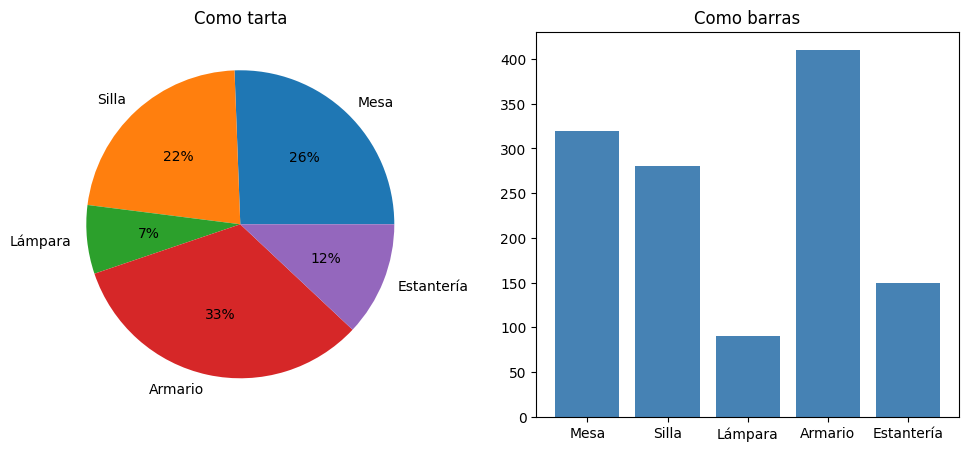

In [20]:
productos_5 = ["Mesa", "Silla", "Lámpara", "Armario", "Estantería"]
ventas_5 = [320, 280, 90, 410, 150]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(ventas_5, labels=productos_5, autopct="%1.0f%%")
axes[0].set_title("Como tarta")

axes[1].bar(productos_5, ventas_5, color="steelblue")
axes[1].set_title("Como barras")

plt.show()


> 💡 Esta solución ya usa `plt.subplots(1, 2, ...)` para poner dos gráficos
> uno al lado del otro — lo verás formalmente en la siguiente sección, pero
> aquí queda claro de un vistazo por qué las barras suelen ganar la
> comparación.


## 7. Boxplot — distribución y outliers de varias variables a la vez

**Qué es:** un resumen visual de una distribución usando 5 números: el
mínimo, el primer cuartil, la mediana, el tercer cuartil y el máximo — más
los posibles outliers, marcados como puntos sueltos.

### 🎈 Analogía sencilla

Es como una "foto de grupo" de los datos: la caja central muestra dónde
está el 50% "típico" de los valores, la línea de en medio es el valor
central (mediana), y los bigotes muestran hasta dónde llegan los valores
normales — cualquier punto que se quede muy lejos de los bigotes se marca
aparte, como un outlier.

### 📊 Representación visual

```
        outlier ●
            │
        ┌───┴───┐  ← máximo "normal" (bigote superior)
        │       │
        ├───────┤  ← tercer cuartil (75% de los datos por debajo)
        │───────│  ← mediana
        ├───────┤  ← primer cuartil (25% de los datos por debajo)
        │       │
        └───┬───┘  ← mínimo "normal" (bigote inferior)
            │
        outlier ●
```

### 🐍 Código Python


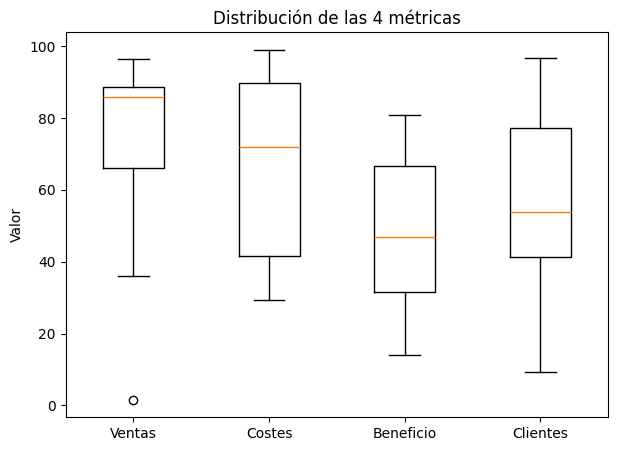

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(
    [df["Ventas"], df["Costes"], df["Beneficio"], df["Clientes"]],
    tick_labels=["Ventas", "Costes", "Beneficio", "Clientes"],
)

ax.set_title("Distribución de las 4 métricas")
ax.set_ylabel("Valor")

plt.show()


### 🔍 Explicación línea a línea

- `ax.boxplot([...], tick_labels=[...])` → recibe una **lista de
  columnas/series**, una por cada caja que quieras dibujar, y sus etiquetas
  correspondientes en el mismo orden.
- Los puntos sueltos por encima o debajo de los bigotes son los outliers
  que detecta Matplotlib automáticamente (usando una regla estadística
  estándar basada en los cuartiles).

### 💼 Aplicación profesional

El boxplot es la forma más rápida de comparar la **dispersión** de varias
métricas a la vez (¿cuál varía más?, ¿cuál tiene outliers?), algo que un
histograma por variable no te deja ver de un solo vistazo.

---

### 📝 Ejercicio 7 (avanzado) — Boxplot con outliers de verdad

Crea una nueva columna `df["Ventas_con_outlier"]` que sea una copia de
`df["Ventas"]` pero con un valor cambiado a `500` (claramente fuera de
rango). Dibuja el boxplot de esa columna sola y comprueba que el outlier
aparece marcado como un punto.


In [22]:
# Ejercicio 7 — Tu código aquí


#### 💡 Solución — Ejercicio 7


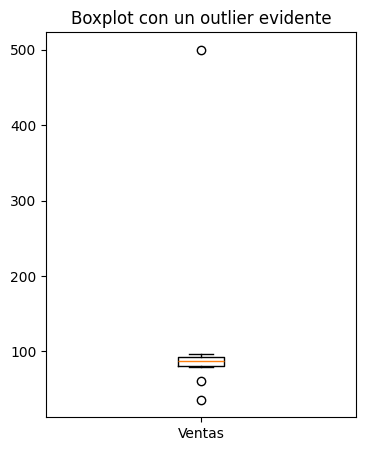

In [23]:
df["Ventas_con_outlier"] = df["Ventas"].copy()
df.loc[0, "Ventas_con_outlier"] = 500

fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(df["Ventas_con_outlier"], tick_labels=["Ventas"])
ax.set_title("Boxplot con un outlier evidente")
plt.show()


## 8. `subplots` — varios gráficos en una sola figura

**Qué es:** dividir una `Figure` en una cuadrícula de varios `Axes`, para
mostrar varios gráficos relacionados juntos, como un mini-dashboard.

### 🐍 Código Python


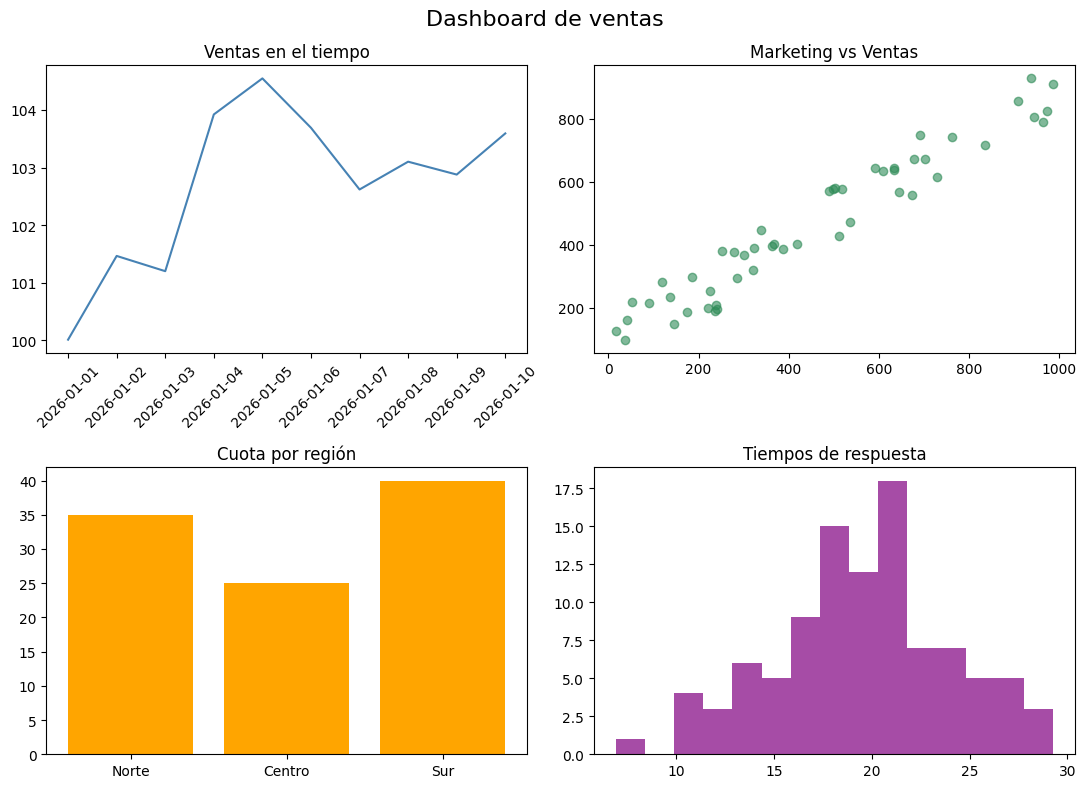

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(fechas, valores_tiempo, color="steelblue")
axes[0, 0].set_title("Ventas en el tiempo")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].scatter(x, y, color="seagreen", alpha=0.6)
axes[0, 1].set_title("Marketing vs Ventas")

axes[1, 0].bar(categorias, valores, color="orange")
axes[1, 0].set_title("Cuota por región")

axes[1, 1].hist(datos_1d, bins=15, color="purple", alpha=0.7)
axes[1, 1].set_title("Tiempos de respuesta")

fig.suptitle("Dashboard de ventas", fontsize=16)
plt.tight_layout()
plt.show()


### 🔍 Explicación línea a línea

- `plt.subplots(2, 2, ...)` → crea una cuadrícula de 2 filas × 2 columnas, y
  `axes` es ahora un array de NumPy de 2x2 con un `Axes` en cada celda —
  por eso se accede con `axes[fila, columna]`, exactamente igual que
  indexabas matrices en el notebook de NumPy.
- Cada `axes[i, j]` se comporta como un `Axes` normal e independiente: su
  propio `.plot()`, `.set_title()`, etc.
- `fig.suptitle(...)` → un título para **toda la figura**, por encima de
  los 4 gráficos (distinto de `ax.set_title()`, que pone título a un solo
  gráfico).
- `plt.tight_layout()` → ajusta automáticamente los espacios para que los
  títulos y etiquetas no se solapen entre subplots — casi siempre conviene
  añadirlo cuando hay varios `Axes`.

### ⚠️ Error común

Si pides una cuadrícula de una sola fila o columna (`plt.subplots(1, 3)`),
`axes` deja de ser una matriz 2D y pasa a ser un array 1D — tendrías que
indexarlo como `axes[0]`, `axes[1]`, `axes[2]`, no con dos índices. El
número de filas/columnas que pidas cambia la "forma" de `axes`.

### 💼 Aplicación profesional

Esto es, literalmente, cómo se construye un dashboard estático con
Matplotlib — el equivalente de una página de Power BI con varias
visualizaciones, pero generado por código.

---

### 📝 Ejercicio 8 (avanzado) — Cuadrícula de 1x3

Crea una figura con `plt.subplots(1, 3, ...)` y coloca en cada hueco: el
boxplot de `df["Ventas"]`, el histograma de `datos_1d`, y el gráfico de
barras de `categorias`/`valores`. Recuerda que con una sola fila, `axes` se
indexa con un único número.


In [25]:
# Ejercicio 8 — Tu código aquí


#### 💡 Solución — Ejercicio 8


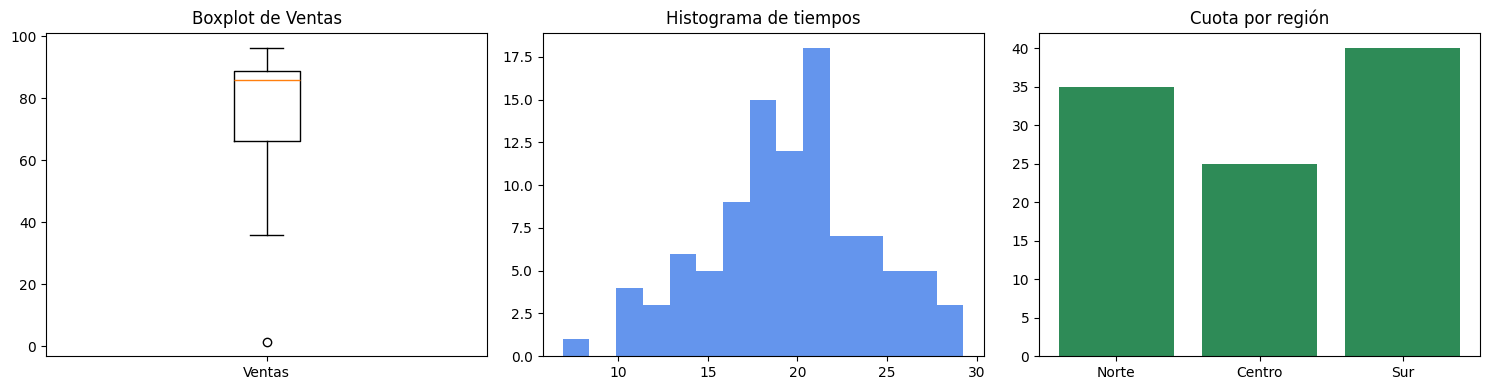

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(df["Ventas"], tick_labels=["Ventas"])
axes[0].set_title("Boxplot de Ventas")

axes[1].hist(datos_1d, bins=15, color="cornflowerblue")
axes[1].set_title("Histograma de tiempos")

axes[2].bar(categorias, valores, color="seagreen")
axes[2].set_title("Cuota por región")

plt.tight_layout()
plt.show()


## 9. Personalización: colores, leyendas, anotaciones y estilos

**Qué es:** el conjunto de opciones que convierten un gráfico "correcto" en
uno "presentable", listo para un informe o una presentación.

### 🐍 Código Python: anotaciones y estilo


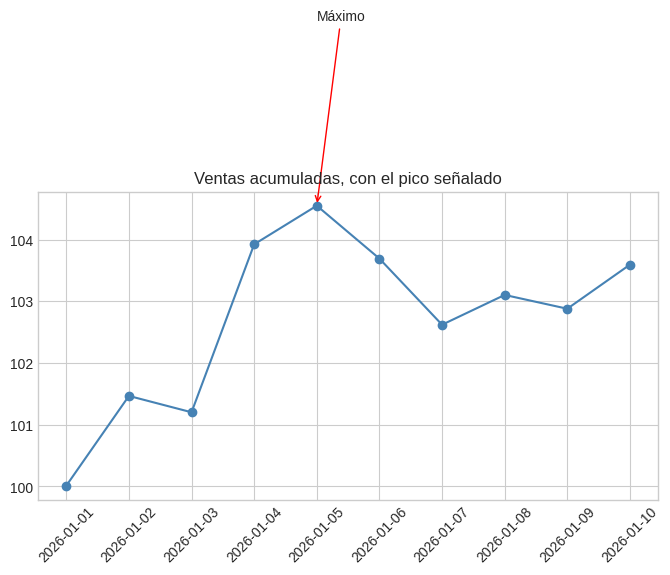

In [27]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fechas, valores_tiempo, color="steelblue", marker="o")

# Anotar el punto máximo directamente sobre el gráfico
idx_max = valores_tiempo.argmax()
ax.annotate(
    "Máximo",
    xy=(fechas[idx_max], valores_tiempo[idx_max]),
    xytext=(fechas[idx_max], valores_tiempo[idx_max] + 3),
    arrowprops=dict(arrowstyle="->", color="red"),
)

ax.set_title("Ventas acumuladas, con el pico señalado")
ax.tick_params(axis="x", rotation=45)
plt.show()


### 🔍 Explicación línea a línea

- `plt.style.use("seaborn-v0_8-whitegrid")` → aplica un conjunto de
  estilos predefinidos (colores, fondo, rejilla) a **todos** los gráficos
  que dibujes después de esta línea, sin tener que configurar cada detalle
  a mano. Hay muchos estilos disponibles (`plt.style.available` los lista
  todos).
- `ax.annotate(texto, xy=, xytext=, arrowprops=)` → dibuja una flecha desde
  `xytext` (dónde va el texto) hasta `xy` (el punto exacto que señalas),
  perfecto para destacar un dato concreto directamente sobre el gráfico, en
  vez de explicarlo aparte.
- `idx_max = valores_tiempo.argmax()` → ya conoces esto de NumPy: la
  posición del valor más alto, para poder señalarlo automáticamente sin
  mirarlo a mano.

### 💼 Aplicación profesional

Un estilo consistente en todos los gráficos de un informe (la misma paleta
de colores, el mismo estilo de fondo) es lo que diferencia un conjunto de
gráficos que "parecen de la misma casa" de una colección desordenada — algo
que en tu caso ya cuidas en Power BI con una plantilla de marca, y aquí se
consigue con `plt.style.use()` o configurando tus propios valores por
defecto al principio del script.

---

### 📝 Ejercicio 9 (avanzado) — Señala el peor día

Sobre el gráfico de líneas de `valores_tiempo`, usa `ax.annotate()` para
señalar el punto **mínimo** de la serie (pista: `argmin()` en vez de
`argmax()`).


In [28]:
# Ejercicio 9 — Tu código aquí


#### 💡 Solución — Ejercicio 9


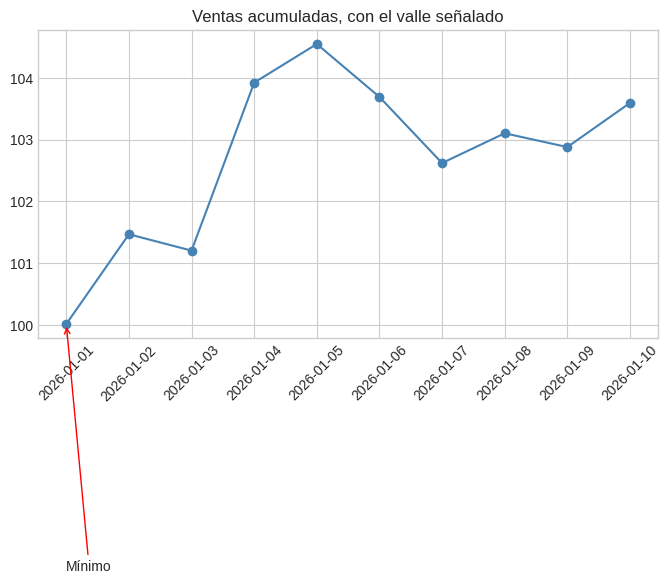

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fechas, valores_tiempo, color="steelblue", marker="o")

idx_min = valores_tiempo.argmin()
ax.annotate(
    "Mínimo",
    xy=(fechas[idx_min], valores_tiempo[idx_min]),
    xytext=(fechas[idx_min], valores_tiempo[idx_min] - 4),
    arrowprops=dict(arrowstyle="->", color="red"),
)

ax.set_title("Ventas acumuladas, con el valle señalado")
ax.tick_params(axis="x", rotation=45)
plt.show()


## 10. Guardar gráficos a fichero

**Qué es:** exportar un gráfico como imagen, para usarlo fuera del
notebook (un informe en Word, una presentación, una página web).

### 🐍 Código Python


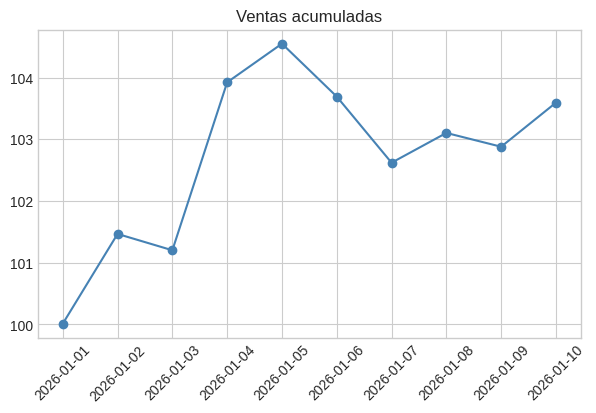

Guardado correctamente.


In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fechas, valores_tiempo, color="steelblue", marker="o")
ax.set_title("Ventas acumuladas")
ax.tick_params(axis="x", rotation=45)

fig.savefig("grafico_ventas.png", dpi=200, bbox_inches="tight")
plt.show()

print("Guardado correctamente.")


### 🔍 Explicación línea a línea

- `fig.savefig("nombre.png", dpi=200, bbox_inches="tight")` → guarda **la
  figura completa** (no solo un `Axes`) en disco. `dpi` controla la
  resolución (más alto = más nítido, pero archivo más pesado). `bbox_inches
  ="tight"` recorta los márgenes en blanco sobrantes alrededor del gráfico.
- El formato se decide por la extensión del nombre de archivo: `.png`,
  `.jpg`, `.pdf`, `.svg` son todos válidos.

### ⚠️ Error común

Llamar a `fig.savefig()` **después** de `plt.show()`: en algunos entornos
(no en Jupyter, pero sí en scripts `.py` normales), `plt.show()` puede
"vaciar" la figura de memoria, dejando el archivo guardado en blanco.
Conviene guardar siempre antes de mostrar, como en el ejemplo de arriba.

### 💼 Aplicación profesional

Saber exportar a `.png`/`.pdf` con buena resolución es necesario en cuanto
quieras meter un gráfico de Python en un Word, un PDF, o una presentación,
en vez de dejarlo solo dentro del notebook.

---

### 📝 Ejercicio 10 (intermedio) — Guardar el dashboard

Vuelve a crear el dashboard de 2x2 de la sección de `subplots`, y guárdalo
como `"dashboard_ventas.png"` con `dpi=150`.


In [31]:
# Ejercicio 10 — Tu código aquí


#### 💡 Solución — Ejercicio 10


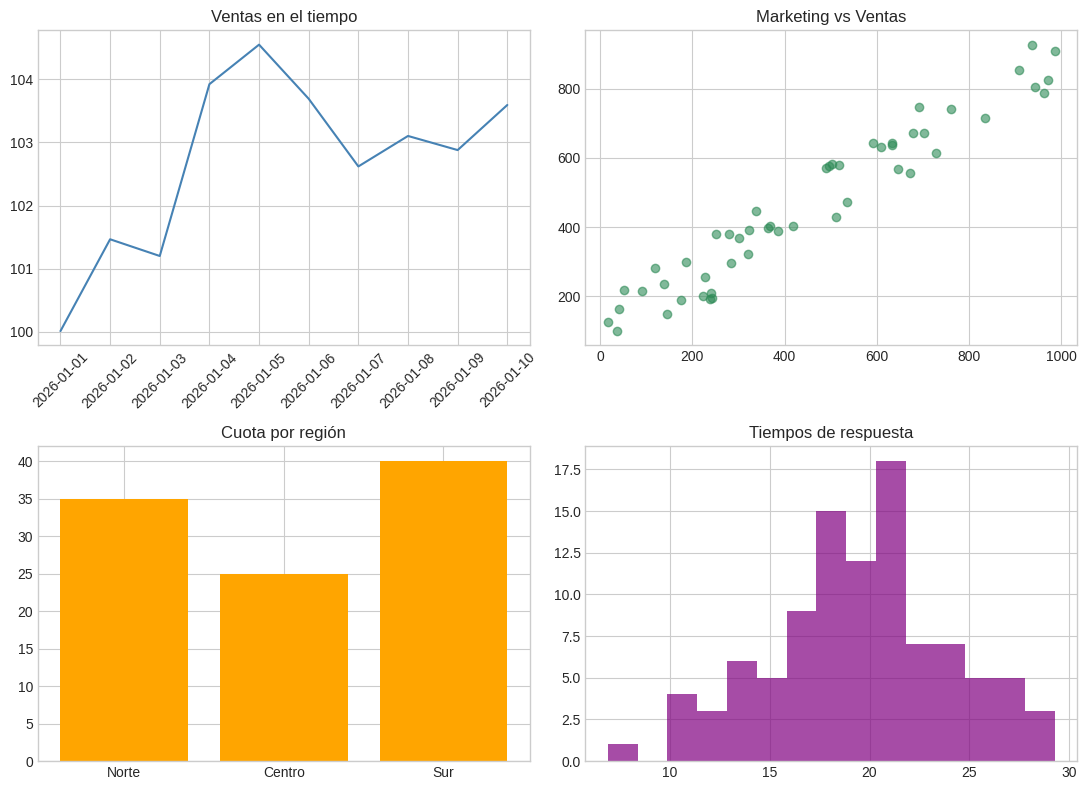

Dashboard guardado.


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(fechas, valores_tiempo, color="steelblue")
axes[0, 0].set_title("Ventas en el tiempo")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].scatter(x, y, color="seagreen", alpha=0.6)
axes[0, 1].set_title("Marketing vs Ventas")

axes[1, 0].bar(categorias, valores, color="orange")
axes[1, 0].set_title("Cuota por región")

axes[1, 1].hist(datos_1d, bins=15, color="purple", alpha=0.7)
axes[1, 1].set_title("Tiempos de respuesta")

plt.tight_layout()
fig.savefig("dashboard_ventas.png", dpi=150, bbox_inches="tight")
plt.show()

print("Dashboard guardado.")


## 📝 Resumen — Cheat sheet de gráficos

| Pregunta de negocio | Gráfico | Función |
|---|---|---|
| ¿Cómo evoluciona algo en el tiempo? | Líneas | `ax.plot()` |
| ¿Están relacionadas dos variables? | Dispersión | `ax.scatter()` |
| ¿Cómo se comparan varias categorías? | Barras | `ax.bar()` / `ax.barh()` |
| ¿Cómo se distribuye una variable numérica? | Histograma | `ax.hist()` |
| ¿Qué proporción del total representa cada parte? | Tarta (con cautela) | `ax.pie()` |
| ¿Cómo se compara la dispersión de varias métricas? | Boxplot | `ax.boxplot()` |
| ¿Necesito varios gráficos juntos? | Cuadrícula | `plt.subplots(filas, columnas)` |

## 🔜 Próximos pasos

Con esto cubres prácticamente todo lo que se puede construir con
`matplotlib.pyplot`. El siguiente paso natural de tu hoja de ruta es
**Seaborn**, una librería construida encima de Matplotlib que simplifica
mucho la sintaxis para gráficos estadísticos (y conecta directamente con
DataFrames de Pandas), aunque por debajo sigue usando exactamente los
mismos conceptos de `Figure` y `Axes` que ya conoces.


## 🏆 Ejercicio final — Nivel Pro: tu propio dashboard

Construye una figura de 2x3 (2 filas, 3 columnas) que sea un mini-informe
visual completo:

1. Líneas: `valores_tiempo` en el tiempo.
2. Dispersión: `x` vs `y`, con color según `tamano_cliente` (puedes
   reutilizar la variable de la sección 3, o crear una nueva).
3. Barras horizontales: `categorias`/`valores`, ordenadas de mayor a menor.
4. Histograma: `datos_1d`, con una línea vertical en la media.
5. Tarta: las mismas `categorias`/`valores` (para comparar con las barras).
6. Boxplot: las 4 columnas originales de `df` (sin la columna con outlier).

Añade un `fig.suptitle()` para todo el conjunto, usa `plt.tight_layout()`,
y guarda el resultado como `"informe_completo.png"`.


In [33]:
# Ejercicio Final — Tu código aquí


#### 💡 Solución — Ejercicio Final


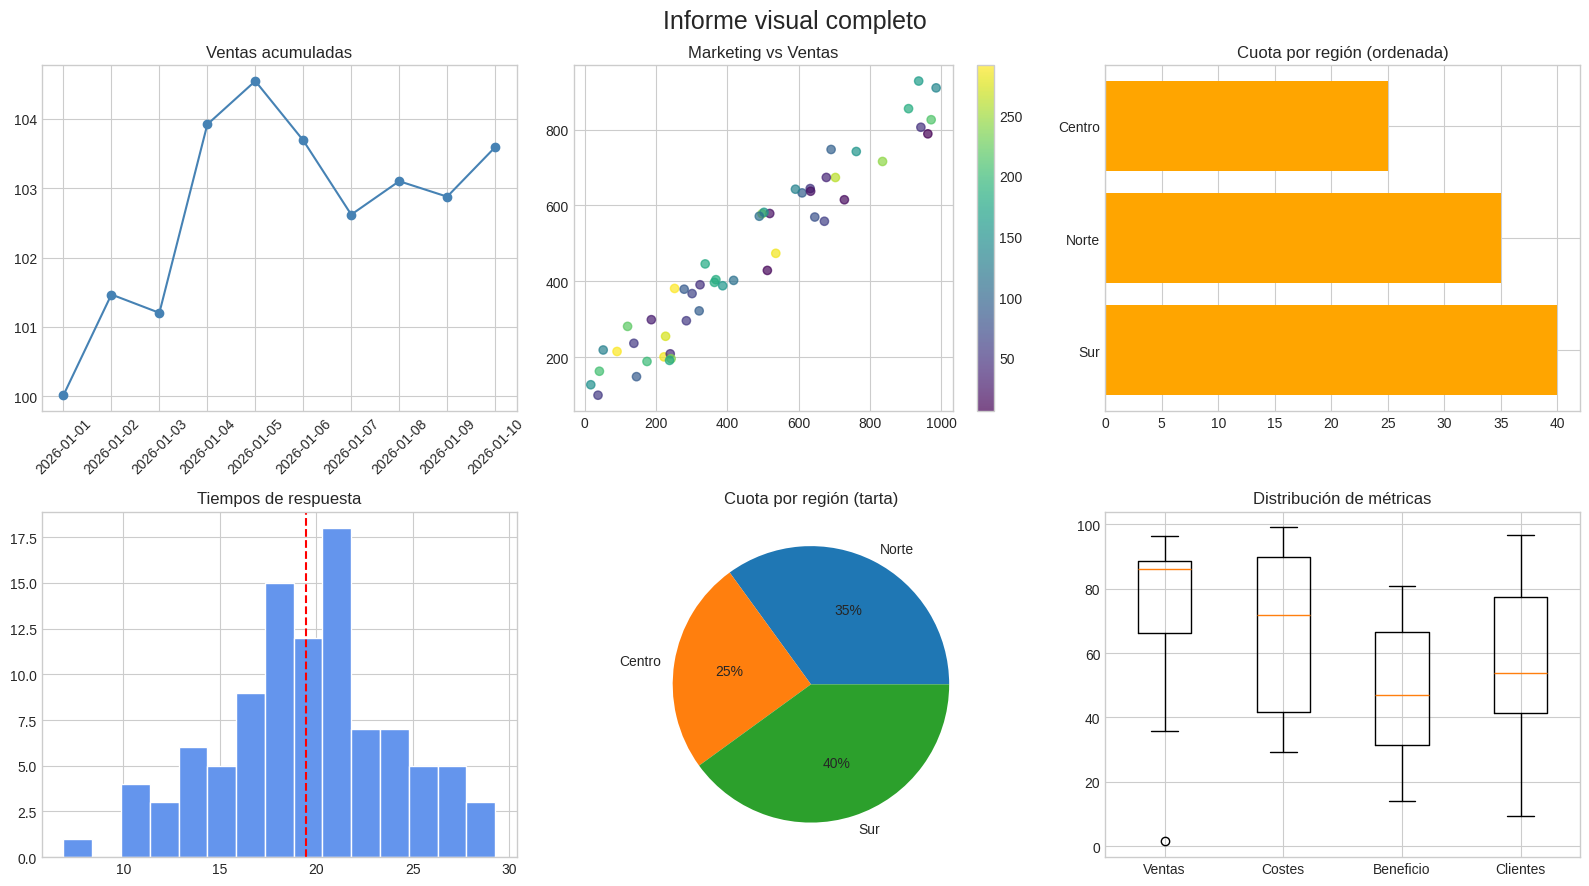

Informe completo guardado como informe_completo.png


In [34]:
np.random.seed(42)
tamano_cliente = np.random.rand(50) * 300

orden = np.argsort(valores)[::-1]
categorias_ordenadas = np.array(categorias)[orden]
valores_ordenados = np.array(valores)[orden]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].plot(fechas, valores_tiempo, color="steelblue", marker="o")
axes[0, 0].set_title("Ventas acumuladas")
axes[0, 0].tick_params(axis="x", rotation=45)

disp = axes[0, 1].scatter(x, y, c=tamano_cliente, cmap="viridis", alpha=0.7)
axes[0, 1].set_title("Marketing vs Ventas")
fig.colorbar(disp, ax=axes[0, 1])

axes[0, 2].barh(categorias_ordenadas, valores_ordenados, color="orange")
axes[0, 2].set_title("Cuota por región (ordenada)")

axes[1, 0].hist(datos_1d, bins=15, color="cornflowerblue", edgecolor="white")
axes[1, 0].axvline(datos_1d.mean(), color="red", linestyle="--")
axes[1, 0].set_title("Tiempos de respuesta")

axes[1, 1].pie(valores, labels=categorias, autopct="%1.0f%%")
axes[1, 1].set_title("Cuota por región (tarta)")

axes[1, 2].boxplot(
    [df["Ventas"], df["Costes"], df["Beneficio"], df["Clientes"]],
    tick_labels=["Ventas", "Costes", "Beneficio", "Clientes"],
)
axes[1, 2].set_title("Distribución de métricas")

fig.suptitle("Informe visual completo", fontsize=18)
plt.tight_layout()
fig.savefig("informe_completo.png", dpi=150, bbox_inches="tight")
plt.show()

print("Informe completo guardado como informe_completo.png")


Si has llegado hasta aquí entendiendo cada pieza, ya sabes construir un
informe visual completo con Matplotlib de principio a fin. 🎉
